In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector

In [2]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Sushil@0711",
    database="superstore_analysis"
)

print("Connection successful!")


Connection successful!


In [3]:
query1 = """
SELECT * FROM superstore; 
""" 
df1 = pd.read_sql(query1, conn)
df1

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_35004/4022759201.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(query1, conn)


,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,sales,quantity,discount,profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.00,41.91
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.00,219.58
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2,0.00,6.87
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5,0.45,-383.03
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2,0.20,2.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.25,3,0.20,4.10
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.96,2,0.00,15.63
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.58,2,0.20,19.39
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.60,4,0.00,13.32


In [4]:
# Total sales and profit
query2 = """
SELECT
    ROUND(SUM(sales),2) AS total_sales,
    ROUND(SUM(profit),2) AS total_profit
FROM superstore;
""" 
df2 = pd.read_sql(query2, conn)
df2

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_35004/579130432.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query2, conn)


,total_sales,total_profit
0,2297201.07,286397.79


In [5]:
# Sales by region
query3 = """
SELECT
    region,
    ROUND(SUM(sales),2) AS total_sales
FROM superstore
GROUP BY region
ORDER BY total_sales DESC
""" 

df3 = pd.read_sql(query3, conn)
df3

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_35004/3870760959.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql(query3, conn)


,region,total_sales
0,West,725457.93
1,East,678781.36
2,Central,501239.88
3,South,391721.90


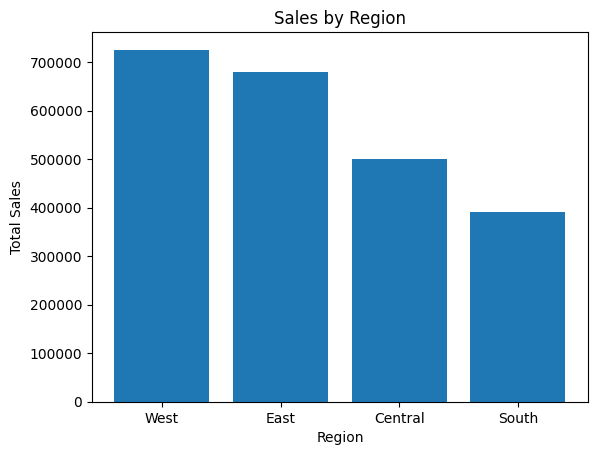

In [6]:
# Visualzation of Sales by region 
plt.bar(df3["region"], df3["total_sales"])
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

In [7]:
# Most profitable states
query4 = """
SELECT
    state,
    ROUND(SUM(profit),2) AS total_profit
FROM superstore
GROUP BY state
ORDER BY total_profit DESC
LIMIT 10; 
"""
df4 = pd.read_sql(query4, conn)
df4

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_35004/1717144286.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df4 = pd.read_sql(query4, conn)


,state,total_profit
0,California,76381.60
1,New York,74038.64
2,Washington,33402.70
3,Michigan,24463.15
4,Virginia,18598.00
5,Indiana,18382.97
6,Georgia,16250.08
7,Kentucky,11199.70
8,Minnesota,10823.22
9,Delaware,9977.37


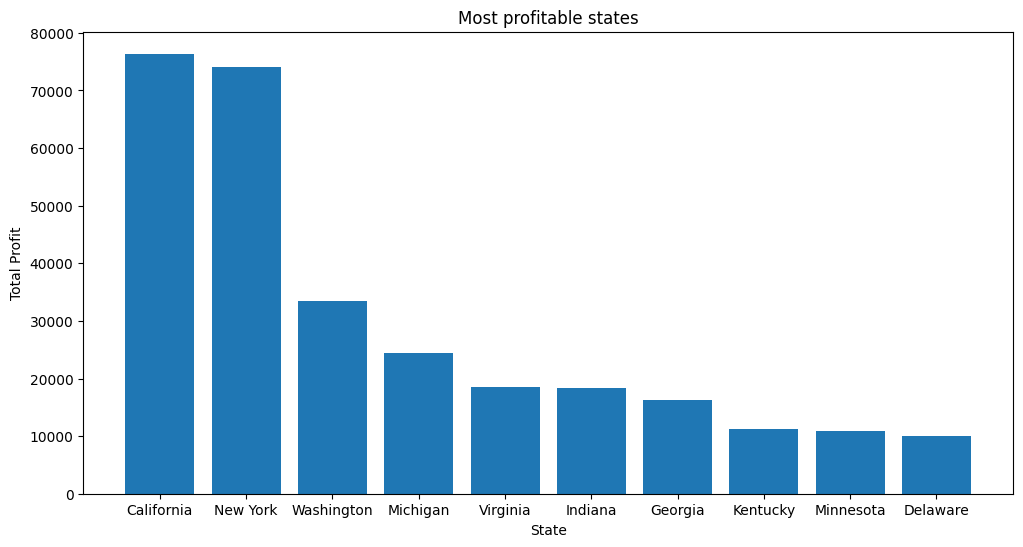

In [8]:
# Visualzation of Most profitable states
plt.figure(figsize=(12,6))
plt.bar(df4["state"], df4["total_profit"])
plt.title("Most profitable states")
plt.xlabel("State")
plt.ylabel("Total Profit")

plt.show()

In [9]:
# Loss-making states 
query5 = """
SELECT
    state,
    ROUND(SUM(profit),2) AS total_profit
FROM superstore
GROUP BY state
HAVING total_profit < 0
ORDER BY total_profit; 
"""
df5 = pd.read_sql(query5, conn)
df5 

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_35004/4214983875.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df5 = pd.read_sql(query5, conn)


,state,total_profit
0,Texas,-25729.29
1,Ohio,-16971.37
2,Pennsylvania,-15560.04
3,Illinois,-12607.89
4,North Carolina,-7490.81
5,Colorado,-6527.86
6,Tennessee,-5341.66
7,Arizona,-3427.87
8,Florida,-3399.25
9,Oregon,-1190.48


In [10]:
# Top categories 
query6 = """
SELECT
    category,
    ROUND(SUM(sales),2) AS sales
FROM superstore
GROUP BY category
ORDER BY sales DESC; 
"""
df6 = pd.read_sql(query6, conn)
df6 

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_35004/2568812795.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df6 = pd.read_sql(query6, conn)


,category,sales
0,Technology,836154.10
1,Furniture,741999.98
2,Office Supplies,719046.99


<Axes: xlabel='category', ylabel='sales'>

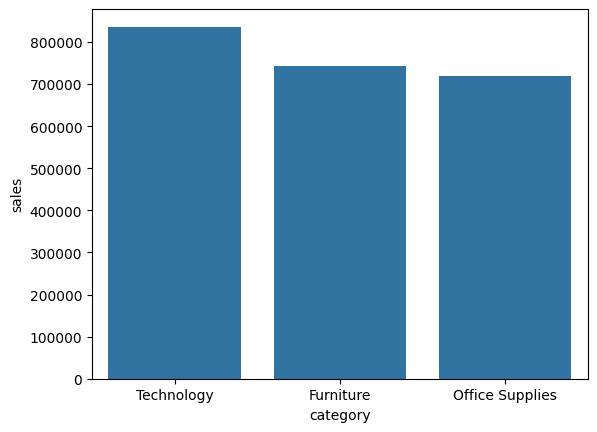

In [11]:
# Visualization of Top categories 
import seaborn as sns
sns.barplot(x='category', y='sales', data=df6)

In [12]:
# Average discount by category 
query7 = """
SELECT
    category,
    ROUND(AVG(discount),2) AS avg_discount
FROM superstore
GROUP BY category;
"""
df7 = pd.read_sql(query7, conn)
df7

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_35004/3751259207.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df7 = pd.read_sql(query7, conn)


,category,avg_discount
0,Furniture,0.17
1,Office Supplies,0.16
2,Technology,0.13


In [13]:
# Discount vs profit
query8 = """
SELECT
    discount,
    ROUND(SUM(profit),2) AS profit
FROM superstore
GROUP BY discount
ORDER BY discount;
""" 
df8 = pd.read_sql(query8, conn)
df8

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_35004/2632642408.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df8 = pd.read_sql(query8, conn)


,discount,profit
0,0.00,320987.88
1,0.10,9029.21
2,0.15,1418.98
3,0.20,90338.16
4,0.30,-10369.34
5,0.32,-2391.16
6,0.40,-23057.08
7,0.45,-2493.12
8,0.50,-20506.51
9,0.60,-5944.64


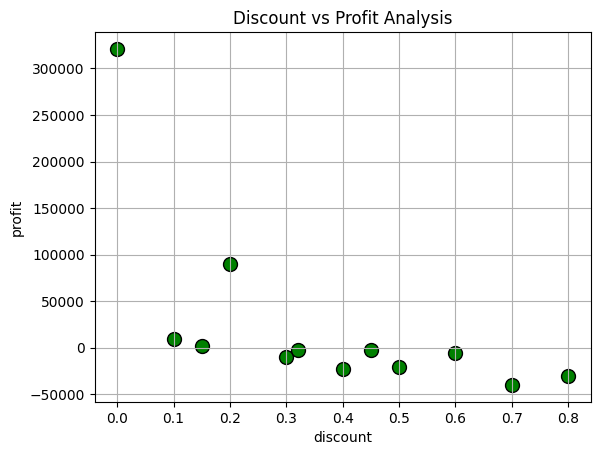

In [14]:
# Visualization of Discount vs profit 
sns.scatterplot(
    x="discount",
    y="profit",
    data=df8,
    color="green",
    s=100,
    edgecolor="black",  
    linewidth=1  
)

plt.title("Discount vs Profit Analysis") 
plt.grid()
plt.show()

In [15]:
# Top 10 cities 
query9 = """
SELECT
    city,
    ROUND(SUM(sales),2) AS sales
FROM superstore
GROUP BY city
ORDER BY sales DESC
LIMIT 10;
""" 
df9 = pd.read_sql(query9, conn)
df9 

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_35004/251916743.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df9 = pd.read_sql(query9, conn)


,city,sales
0,New York City,256368.12
1,Los Angeles,175851.33
2,Seattle,119540.74
3,San Francisco,112669.09
4,Philadelphia,109077.09
5,Houston,64504.71
6,Chicago,48539.59
7,San Diego,47521.05
8,Jacksonville,44713.18
9,Springfield,43054.35


In [16]:
# Shipping mode usage 
query10 = """
SELECT
    ship_mode,
    COUNT(*) AS total_orders
FROM superstore
GROUP BY ship_mode
ORDER BY total_orders DESC;
""" 
df10 = pd.read_sql(query10, conn)
df10

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_35004/4136498339.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df10 = pd.read_sql(query10, conn)


,ship_mode,total_orders
0,Standard Class,5968
1,Second Class,1945
2,First Class,1538
3,Same Day,543


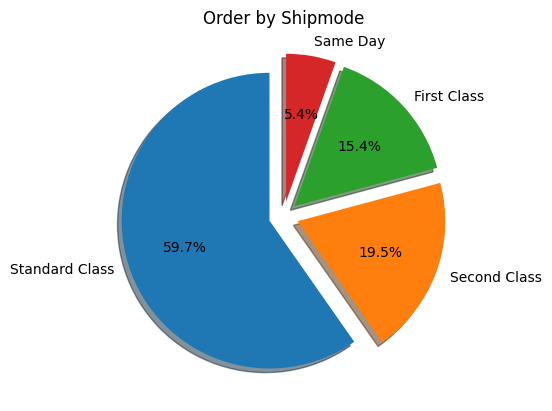

In [17]:
# Visualization of shipping mode Usage 
labels = ['Standard Class', 'Second Class', 'First Class', 'Same Day']
values = [5968,1945,1538,543]

plt.pie(
    values,
    labels=labels, 
    autopct='%1.1f%%',
    startangle=90,
    explode = [0.1,0.1,0.1,0.1],      
    shadow=True       
)

plt.title("Order by Shipmode")
plt.show()


In [18]:
# Find top state by sales in each region using window function ranking
query11 = """
SELECT *
FROM (
    SELECT
        region,
        state,
        SUM(sales) AS total_sales,
        RANK() OVER (
            PARTITION BY region
            ORDER BY SUM(sales) DESC
        ) AS ranking
    FROM superstore
    GROUP BY region, state
) ranked
WHERE ranking = 1;
""" 
df11 = pd.read_sql(query11, conn)
df11

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_35004/2104082942.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df11 = pd.read_sql(query11, conn)


,region,state,total_sales,ranking
0,Central,Texas,170187.98,1
1,East,New York,310876.20,1
2,South,Florida,89473.73,1
3,West,California,457687.68,1
